In [ ]:
import pandas as pd

github link: https://github.com/Arooba10467/AI-Artificial-Intelligence-CSC4101

In [ ]:
df = pd.read_csv("/content/Pakistan Largest Ecommerce Dataset.csv")

/tmp/ipykernel_824/138652978.py:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Pakistan Largest Ecommerce Dataset.csv")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

In [ ]:
df.shape

(1048575, 26)

In [ ]:
import numpy as np

In [ ]:
df.describe()

,item_id,price,qty_ordered,grand_total,discount_amount,Year,Month,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,584524.000000,5.845240e+05,584524.000000,5.845240e+05,584524.000000,584524.000000,584524.000000,584513.000000,0.0,0.0,0.0,0.0,0.0
mean,565667.074218,6.348748e+03,1.296388,8.530619e+03,499.492775,2017.044115,7.167654,45790.511965,NaN,NaN,NaN,NaN,NaN
std,200121.173648,1.494927e+04,3.996061,6.132081e+04,1506.943046,0.707355,3.486305,34414.962389,NaN,NaN,NaN,NaN,NaN
min,211131.000000,0.000000e+00,1.000000,-1.594000e+03,-599.500000,2016.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,395000.750000,3.600000e+02,1.000000,9.450000e+02,0.000000,2017.000000,4.000000,13516.000000,NaN,NaN,NaN,NaN,NaN
50%,568424.500000,8.990000e+02,1.000000,1.960400e+03,0.000000,2017.000000,7.000000,42856.000000,NaN,NaN,NaN,NaN,NaN
75%,739106.250000,4.070000e+03,1.000000,6.999000e+03,160.500000,2018.000000,11.000000,73536.000000,NaN,NaN,NaN,NaN,NaN
max,905208.000000,1.012626e+06,1000.000000,1.788800e+07,90300.000000,2018.000000,12.000000,115326.000000,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

# **1) Handling Catagorical Data**

**2**) dropping unused columns

In [ ]:
# drop last 6 columns as they all are null
df = df.drop(['Unnamed: 21'], axis=1)


In [ ]:
# drop multiple columns
df = df.drop(['Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25'], axis=1)

In [ ]:
# drop Month, Year, M-Y, M, and FY as we have already Working date that has date info

df = df.drop(['Month', 'Year', 'M-Y', 'FY'], axis=1)

In [ ]:
# also drop 'working date' column as we have 'created_at' column that has date information
df = df.drop(['Working Date'], axis=1)

In [ ]:
# dropping Customer ID , increment_id and item_id
df = df.drop(['item_id', 'increment_id', 'Customer ID'], axis=1)

sales_commisision_code: 447346 - 584524 = 137,178,
*  (137,178 / 584524) * 100 = 23%
*  so almost 23% are null so dropping this column as well



In [ ]:
df = df.drop(['sales_commission_code'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   status           584509 non-null  object 
 1   created_at       584524 non-null  object 
 2   sku              584504 non-null  object 
 3   price            584524 non-null  float64
 4   qty_ordered      584524 non-null  float64
 5   grand_total      584524 non-null  float64
 6   category_name_1  584360 non-null  object 
 7   discount_amount  584524 non-null  float64
 8   payment_method   584524 non-null  object 
 9   BI Status        584524 non-null  object 
 10   MV              584524 non-null  object 
 11  Customer Since   584513 non-null  object 
dtypes: float64(4), object(8)
memory usage: 96.0+ MB


 Mapping catagorical to numerical values

In [ ]:
df['BI Status'].nunique() # BI Status has 4 unique values

4

In [ ]:
df['BI Status'].unique()

array(['#REF!', 'Gross', 'Net', 'Valid', nan], dtype=object)

In [ ]:
df['BI Status'] = df['BI Status'].map({'#REF!' : 1, 'Gross' : 2, 'Net' : 3, 'Valid' : 4})

In [ ]:
df.head(3) # BI status catagorical to numerical check

,status,created_at,sku,price,qty_ordered,grand_total,category_name_1,discount_amount,payment_method,BI Status,MV,Customer Since
0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,Women's Fashion,0.0,cod,1.0,"1,950",2016-7
1,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,Beauty & Grooming,0.0,cod,2.0,240,2016-7
2,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,Women's Fashion,0.0,cod,2.0,"2,450",2016-7



mapping status column with numerical value


In [ ]:
df['status'].nunique()

16

In [ ]:
df['status'].unique()

array(['complete', 'canceled', 'order_refunded', 'received', 'refund',
       'closed', 'fraud', 'holded', 'exchange', 'pending_paypal', 'paid',
       '\\N', 'cod', 'pending', nan, 'processing', 'payment_review'],
      dtype=object)

In [ ]:
df['status'] = df['status'].map({
    'complete' : 0,
    'canceled' : 1,
    'order_refunded' : 3,
    'received' : 4,
    'refund' : 5,
    'closed' : 6,
    'fraud' : 7,
    'holded' : 8,
    'exchange' : 9,
    'pending_paypal' : 10,
    'paid' : 11,
    'cod' : 12,
    'pending' : 13,
    'processing' : 14,
    'payment_review' : 15})

another way that mapps all the values at once

*from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['status'] = le.fit_transform(df['status'])




In [ ]:
df.head(3) # check

,status,created_at,sku,price,qty_ordered,grand_total,category_name_1,discount_amount,payment_method,BI Status,MV,Customer Since
0,0.0,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,Women's Fashion,0.0,cod,1.0,"1,950",2016-7
1,1.0,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,Beauty & Grooming,0.0,cod,2.0,240,2016-7
2,1.0,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,Women's Fashion,0.0,cod,2.0,"2,450",2016-7


mapping catagory_name_1 column into numerical

In [ ]:
df['category_name_1'].nunique()

16

In [ ]:
df['category_name_1'].unique()

array(["Women's Fashion", 'Beauty & Grooming', 'Soghaat',
       'Mobiles & Tablets', 'Appliances', 'Home & Living',
       "Men's Fashion", 'Kids & Baby', '\\N', 'Others', 'Entertainment',
       'Computing', 'Superstore', 'Health & Sports', 'Books',
       'School & Education', nan], dtype=object)

In [ ]:
df['category_name_1'] = df['category_name_1'].map({
   "Women's Fashion" : 0,
   'Beauty & Grooming' :1,
   'Soghaat' : 2,
  'Mobiles & Tablets' : 3,
  'Appliances' : 4,
  'Home & Living' : 5,
  "Men's Fashion" : 6,
   'Kids & Baby' : 7,
   'Others' : 8,
   'Entertainment' : 9,
   'Computing' : 10,
   'Superstore' : 11,
   'Health & Sports' : 12,
   'Books' : 13,
    'School & Education' : 14
})

mapping payment_method

In [ ]:
df['payment_method'].nunique()

18

In [ ]:
df['payment_method'].unique()

array(['cod', 'ublcreditcard', 'mygateway', 'customercredit',
       'cashatdoorstep', 'mcblite', 'internetbanking', 'marketingexpense',
       'productcredit', 'financesettlement', 'Payaxis', 'jazzvoucher',
       'jazzwallet', 'Easypay', 'Easypay_MA', 'easypay_voucher',
       'bankalfalah', 'apg', nan], dtype=object)

In [ ]:
df['payment_method'] = df['payment_method'].map({
    'cod' : 0,
    'ublcreditcard' : 1,
    'mygateway' : 2,
    'customercredit' : 3,
    'cashatdoorstep' : 4,
    'mcblite' : 5,
    'internetbanking' : 6,
    'marketingexpense' : 7,
    'productcredit' : 8,
    'financesettlement' : 9,
    'Payaxis' : 10,
    'jazzvoucher' : 11,
    'jazzwallet' : 12,
    'Easypay' : 13,
    'Easypay_MA' : 14,
    'easypay_voucher' : 15,
    'bankalfalah' : 16,
    'apg' : 17
})

In [ ]:
df.head(3) # check

,status,created_at,sku,price,qty_ordered,grand_total,category_name_1,discount_amount,payment_method,BI Status,MV,Customer Since
0,0.0,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,0.0,0.0,0.0,1.0,"1,950",2016-7
1,1.0,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,1.0,0.0,0.0,2.0,240,2016-7
2,1.0,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,0.0,0.0,0.0,2.0,"2,450",2016-7


# 3) **Handling** Null Values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   status           584505 non-null  float64
 1   created_at       584524 non-null  object 
 2   sku              584504 non-null  object 
 3   price            584524 non-null  float64
 4   qty_ordered      584524 non-null  float64
 5   grand_total      584524 non-null  float64
 6   category_name_1  576510 non-null  float64
 7   discount_amount  584524 non-null  float64
 8   payment_method   584524 non-null  float64
 9   BI Status        584524 non-null  float64
 10   MV              584524 non-null  object 
 11  Customer Since   584513 non-null  object 
dtypes: float64(8), object(4)
memory usage: 96.0+ MB


out of 1048574 existing columns only 584524 are fully filled so dropping the rest of huge columns is good approach that simplifies the data. as filling such rows can damage our data

In [ ]:
df.isnull().sum()

,0
status,464070
created_at,464051
sku,464071
price,464051
qty_ordered,464051
grand_total,464051
category_name_1,472065
discount_amount,464051
payment_method,464051
BI Status,464051


almost half of data in each column is missing so removing those unused rows

one way of dropping such rows is
*   df = df.dropna(thresh=6) so it will keep those columns where there are at least 6 non null values




In [ ]:
df = df.dropna(thresh=6)

In [ ]:
# check if the total rows are reduced now
df.shape

(584524, 12)

In [ ]:
# check the range index
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584524 entries, 0 to 584523
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   status           584505 non-null  float64
 1   created_at       584524 non-null  object 
 2   sku              584504 non-null  object 
 3   price            584524 non-null  float64
 4   qty_ordered      584524 non-null  float64
 5   grand_total      584524 non-null  float64
 6   category_name_1  576510 non-null  float64
 7   discount_amount  584524 non-null  float64
 8   payment_method   584524 non-null  float64
 9   BI Status        584524 non-null  float64
 10   MV              584524 non-null  object 
 11  Customer Since   584513 non-null  object 
dtypes: float64(8), object(4)
memory usage: 58.0+ MB


In [ ]:
# now check which columns are left behind with null values
df.isnull().sum()

,0
status,19
created_at,0
sku,20
price,0
qty_ordered,0
grand_total,0
category_name_1,8014
discount_amount,0
payment_method,0
BI Status,0


# **Filling Null values**

There are multiple ways of filling null values depending on the column, we can either fill with 0 or fill with mean or mode

There are 3 columns where we have to fill the null values.
1.   status:
*   19 null values, can be filled with 0.
2.   category_name_1:
*   8014 null values can be filled with mode, thats the most repeated value.
2.   Customer Since:
*   11 null values, can be filled with mode: most repeated value

In [ ]:
# filling status column null values with 0
df['status'] = df['status'].fillna(0)

In [ ]:
# checking all null spaces in status column are  filled with value 0
df['status'].isnull().sum()

np.int64(0)

In [ ]:
# filling with mode
df['category_name_1'] = df['category_name_1'].fillna(df['category_name_1'].mode()[0])

In [ ]:
df['Customer Since'] = df['Customer Since'].fillna(df['Customer Since'].mode()[0])

In [ ]:
# dropping sku as well
df = df.drop(['sku'], axis = 1)

In [ ]:
All null values are filled

In [ ]:
# check null values
df.isnull().sum()

,0
status,0
created_at,0
price,0
qty_ordered,0
grand_total,0
category_name_1,0
discount_amount,0
payment_method,0
BI Status,0
MV,0


# **4) Handling duplicates**

In [ ]:
df.duplicated().sum()

np.int64(165963)

In [ ]:
# removing duplicate values
df = df.drop_duplicates()

In [ ]:
# check
df.duplicated().sum()

np.int64(0)

so now duplicates and null values are handled

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418561 entries, 0 to 584523
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   status           418561 non-null  float64
 1   created_at       418561 non-null  object 
 2   price            418561 non-null  float64
 3   qty_ordered      418561 non-null  float64
 4   grand_total      418561 non-null  float64
 5   category_name_1  418561 non-null  float64
 6   discount_amount  418561 non-null  float64
 7   payment_method   418561 non-null  float64
 8   BI Status        418561 non-null  float64
 9    MV              418561 non-null  object 
 10  Customer Since   418561 non-null  object 
dtypes: float64(8), object(3)
memory usage: 38.3+ MB


In [ ]:
df.isnull().sum()

,0
status,0
created_at,0
price,0
qty_ordered,0
grand_total,0
category_name_1,0
discount_amount,0
payment_method,0
BI Status,0
MV,0


In [ ]:
df.shape

(418561, 11)

For graph import libraries

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


5) correletion and Scattered plot

top 5 most important columns for grandtotal

In [ ]:
#sorted correlation scores in ascending and pick the top 5 giving the location excluding grand_total itself
top_5 = corr_matrix['grand_total'].sort_values(ascending=False).iloc[1:6]
print("5 Most Important Features for Grand Total")
print(top_5)

--- 5 Most Important Features for Grand Total ---
qty_ordered        0.682213
price              0.321162
discount_amount    0.103228
payment_method     0.086737
status            -0.004739
Name: grand_total, dtype: float64


scattered plot of two features, selecting the continuous one to analyse the data, here price vs grandtotal give a positive correlation graph. as prices are low grandtotal data shows high scatterd dense dots and as price of product increases the grandtotal dots decreases. showig people tend to buy cheaper products more than the luxary once, that are bought less frequently

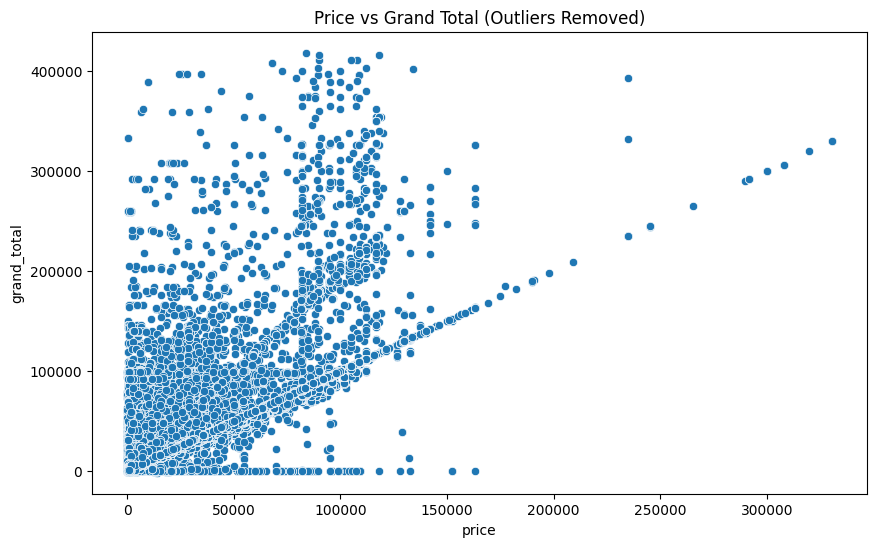

In [ ]:
# Create a "zoomed in" version by filtering out the extreme outliers
df_filtered = df[df['grand_total'] < 418561]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_filtered, x='price', y='grand_total')
plt.title('Price vs Grand Total (Outliers Removed)')
plt.show()

**Outlier**

<Axes: xlabel='grand_total'>

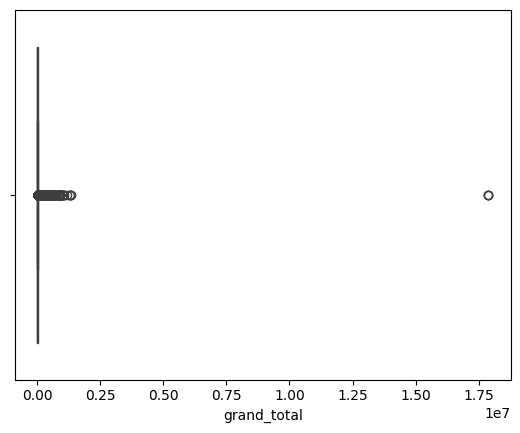

In [ ]:
sns.boxplot(x = df['grand_total'])

In [ ]:
# 1. Identify the 'Grand Total' outliers
Q1 = df['grand_total'].quantile(0.25)
Q3 = df['grand_total'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
# Define the upper and lower 'fences'
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# Handle them by filtering (Removing them from the analysis)
df_no_outliers = df[(df['grand_total'] >= lower_limit) & (df['grand_total'] <= upper_limit)]

the outlier value that existed was 17500000 now reduced to 12000

Outliers removed! New max value: 11542.15


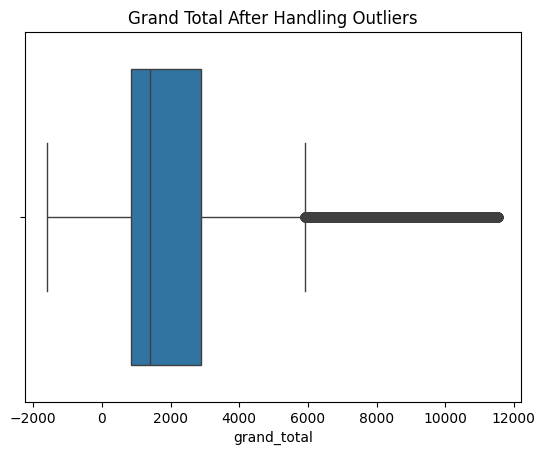

In [ ]:
print(f"Outliers removed! New max value: {df_no_outliers['grand_total'].max()}")
sns.boxplot(x=df_no_outliers['grand_total'])
plt.title("Grand Total After Handling Outliers")
plt.show()

<Axes: xlabel='price'>

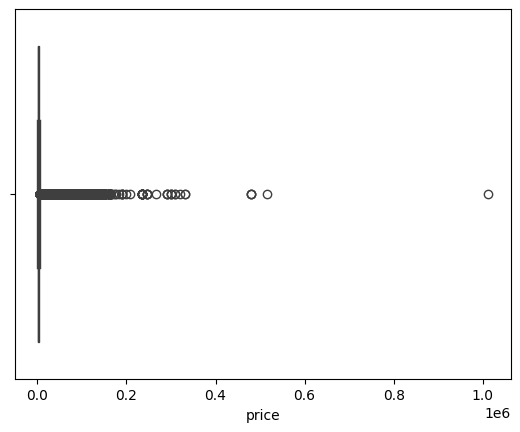

In [ ]:
sns.boxplot(x = df['price'])

the outlier value that existed earlier of 100000 now reduced to 6000 value

Items priced above 5975.00 are considered outliers.


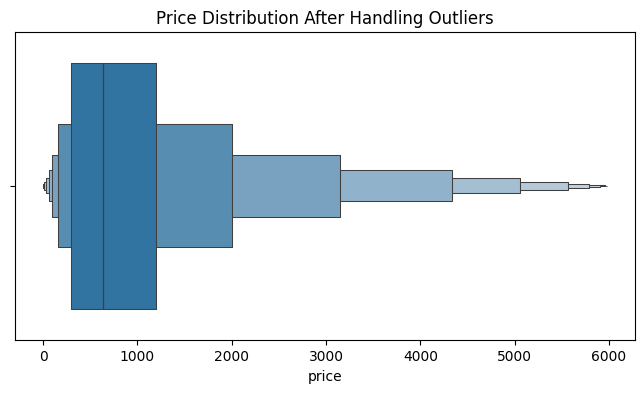

In [ ]:
# Calculate the Quarters
Q1_p = df['price'].quantile(0.25)
Q3_p = df['price'].quantile(0.75)
IQR_p = Q3_p - Q1_p
# Define the 'Upper Fence'
upper_fence_p = Q3_p + 1.5 * IQR_p
print(f"Items priced above {upper_fence_p:.2f} are considered outliers.")
# 3. Create the cleaned dataframe
df_price_clean = df[df['price'] <= upper_fence_p]

plt.figure(figsize=(8, 4))
sns.boxenplot(x=df_price_clean['price'])
plt.title('Price Distribution After Handling Outliers')
plt.show()

# **Data Analytics**

Best Selling Catagory
*  6 thats is men's fashion



In [ ]:
# count how many times each category appears and select the top one
top = df_final['category_name_1'].value_counts().idxmax()
print(f"The top catagory is: {top}")

The top catagory is: 6.0


<Axes: title={'center': 'Most Popular Categories'}, xlabel='category_name_1'>

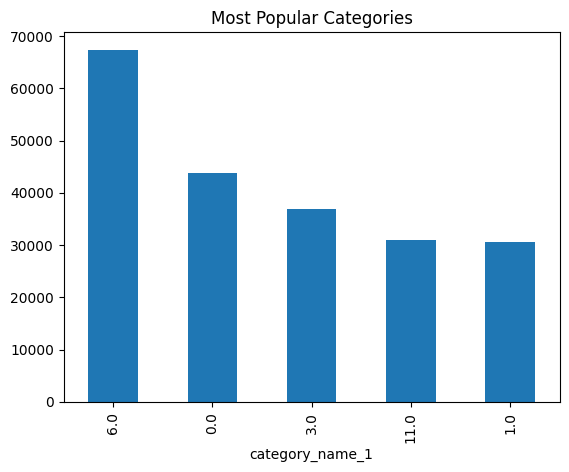

In [ ]:
# visualize form of top five catagories
df_final['category_name_1'].value_counts().head(5).plot(kind='bar', title='Most Popular Categories')

2) Payment & Status Frequency

In [ ]:
# Top 5 payment methods so it stays "Easy"
top_5 = df_final['payment_method'].value_counts().head(5).index
df_easy = df_final[df_final['payment_method'].isin(top_5)]
print(f"top five are : {top_5}")

top five are : Index([0.0, 10.0, 13.0, 12.0, 16.0], dtype='float64', name='payment_method')


the below graph showing high payment_method is 0 thats Cash on deliver COD,
so more people tend towards cod then other options of payment

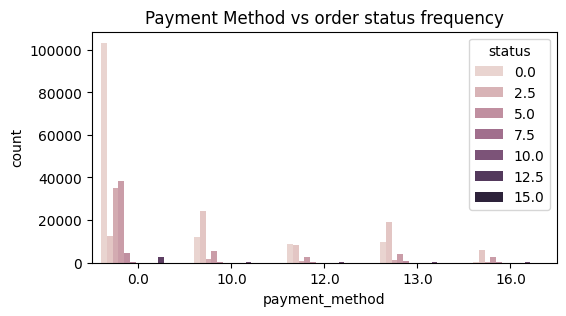

In [ ]:
# graph
plt.figure(figsize=(6, 3))
sns.countplot(data=df_easy, x='payment_method', hue='status')
plt.title('Payment Method vs order status frequency')
plt.show()

3) Find a correlation between payment method and order status

In [ ]:
# Top 5 payment methods
top_5 = df_final['payment_method'].value_counts().head(5).index
df_easy = df_final[df_final['payment_method'].isin(top_5)]
print(f"top five are: {top_5} ")

top five are: Index([0.0, 10.0, 13.0, 12.0, 16.0], dtype='float64', name='payment_method') 


The below diagram tells that cod again cash on delivery has more order status that tells people in pakistan trust more on cash n delivery. and very few people goes to credict card like bankalfallah (16.0).

The below diagram tells that cod again cash on delivery has more order status that tells people in pakistan trust more on cash n delivery. and very few people goes to credict card like bankalfallah (16.0).

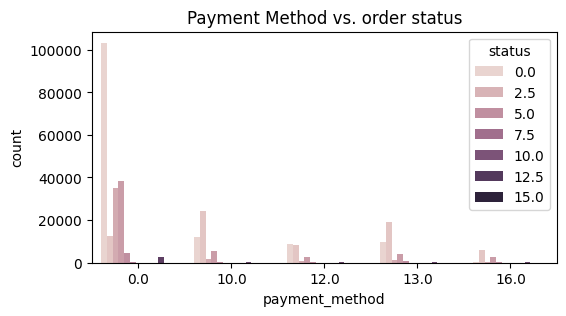

In [ ]:
# graph
plt.figure(figsize=(6, 3))
sns.countplot(data=df_easy, x='payment_method', hue='status')
plt.title('Payment Method vs. order status')
plt.show()

4) order date vs item catagory

/tmp/ipykernel_824/3134804824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['month_name'] = pd.to_datetime(df_final['created_at']).dt.month_name()


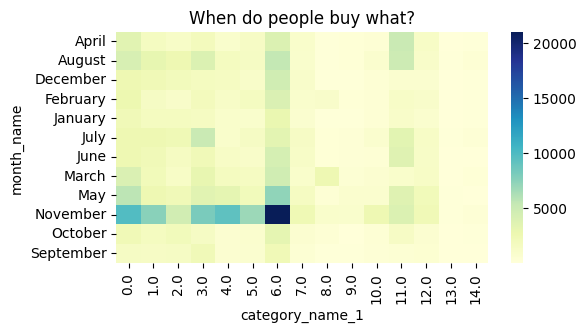

In [ ]:
#  month name
df_final['month_name'] = pd.to_datetime(df_final['created_at']).dt.month_name()

# 2. Make a simple table (Crosstab)
simple_table = pd.crosstab(df_final['month_name'], df_final['category_name_1'])

# 3. Draw the "Weather Map"
plt.figure(figsize=(6, 3))
sns.heatmap(simple_table, cmap="YlGnBu") # Yellow-Green-Blue colors
plt.title('When do people buy what?')
plt.show()

5) Find any hidden patterns that are counter-intuitive for a layman

In 4rth diagram month vs sales, The Darker hues predicting more people bought certain catagory products.
*  like 0-6 catagory products are these
   "Women's Fashion" : 0,
   'Beauty & Grooming' :1,
   'Soghaat' : 2,
  'Mobiles & Tablets' : 3,
  'Appliances' : 4,
  'Home & Living' : 5,
  "Men's Fashion : 6,
*   so above tells that in november there is a largest sell of the year thats 11:11 and most people buy products in the month of november includes beauty products, laptops, mobile, appliances as 4.0 is darker. also mans and fashion is highest that was our statistics as well that grandtotal was of this catagory no 6.0 thats mens and fashion.



in 3rd statistics diagram order vs status tells that cod again cash on delivery has more order status that tells people in pakistan trust more on cash on delivery. and very few people goes to credict card like bankalfallah (16.0).

In 2nd diagram oayment vs status, the graph showing high payment_method mapped with 0 thats Cash on deliver COD,
so more people tend towards cod then other options of payment

the first data anlytics diagram show best selling catagory is of mens and fashion that is mapped with number 6

In [ ]:
df_final.to_csv('preprocessed_data.csv', index=False)